In [1]:
!pip install -q kaggle
!kaggle datasets download -d zalando-research/fashionmnist
!unzip fashionmnist.zip -d fashionmnist/
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import tensorflow as tf
import os
import kagglehub
from matplotlib import pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

Dataset URL: https://www.kaggle.com/datasets/zalando-research/fashionmnist
License(s): other
fashionmnist.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  fashionmnist.zip
replace fashionmnist/fashion-mnist_test.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: N
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
from tensorflow.keras import mixed_precision

mixed_precision.set_global_policy("mixed_float32")

In [3]:
train_df = pd.read_csv('fashionmnist/fashion-mnist_train.csv')
test_df = pd.read_csv('fashionmnist/fashion-mnist_test.csv')

In [4]:
def image_from_row(row, df=train_df):
    return 2*df.iloc[row, 1:].values.reshape(28,28,1)/255 -1

def images_from_df(indices, df=train_df):
    return 2*df.iloc[indices, 1:].values.reshape(len(indices), 28,28,1)/255 -1

In [5]:
def residual_block(x, filters):
    shortcut = x

    if x.shape[-1] != filters:
        shortcut = layers.Conv2D(
            filters,
            1,
            padding="same"
        )(shortcut)

    x = layers.Conv2D(filters, 3, padding="same")(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Conv2D(filters, 3, padding="same")(x)

    x = layers.Add()([x, shortcut])
    x = layers.LeakyReLU(0.2)(x)

    return x

In [6]:
from tensorflow.keras import models, layers
def criar_critico():
  inputs = layers.Input((28,28,1))
  x = layers.Conv2D(64, 3, padding="same")(inputs)
  x = residual_block(x, 64)
  x = residual_block(x, 128)
  x = residual_block(x, 256)
  x = layers.GlobalAveragePooling2D()(x)
  x = layers.Dense(128)(x)
  outputs = layers.Dense(1)(x)
  return models.Model(inputs, outputs)
criar_critico().summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 28, 28,    │        640 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 28, 28,    │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu         │ (None, 28, 28,    │          0 │ conv2d_1[0][0]    │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 28, 28,    │     36,928 │ leaky_re_lu[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 28, 28,    │          0 │ conv2d_2[0][0],   │
│                     │ 64)               │            │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_1       │ (None, 28, 28,    │          0 │ add[0][0]         │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 28, 28,    │     73,856 │ leaky_re_lu_1[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_2       │ (None, 28, 28,    │          0 │ conv2d_4[0][0]    │
│ (LeakyReLU)         │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 28, 28,    │    147,584 │ leaky_re_lu_2[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 28, 28,    │      8,320 │ leaky_re_lu_1[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 28, 28,    │          0 │ conv2d_5[0][0],   │
│                     │ 128)              │            │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_3       │ (None, 28, 28,    │          0 │ add_1[0][0]       │
│ (LeakyReLU)         │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 28, 28,    │    295,168 │ leaky_re_lu_3[0]… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_4       │ (None, 28, 28,    │          0 │ conv2d_7[0][0]    │
│ (LeakyReLU)         │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 28, 28,    │    590,080 │ leaky_re_lu_4[0]… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 28, 28,    │     33,024 │ leaky_re_lu_3[0]

 Total params: 1,255,553 (4.79 MB)

 Trainable params: 1,255,553 (4.79 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
GENERATOR_LATENT_DIM = 512
def criar_gerador():
  inputs = layers.Input((GENERATOR_LATENT_DIM,))
  x = layers.Dense(512)(inputs)
  x = layers.Reshape((4,4,32))(x)
  x = residual_block(x, 128)
  x = layers.UpSampling2D((2,2))(x)
  x = layers.BatchNormalization()(x)
  x = layers.UpSampling2D((2,2))(x)
  x = residual_block(x, 64)
  x = layers.UpSampling2D((2,2))(x)
  x = layers.BatchNormalization()(x)
  x = residual_block(x, 32)
  x = residual_block(x, 16)
  outputs = layers.Conv2D(1, (5, 5), activation='tanh')(x)
  return  models.Model(inputs, outputs)
criar_gerador().summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 512)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 512)       │    262,656 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 4, 4, 32)  │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 4, 4, 128) │     36,992 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_6       │ (None, 4, 4, 128) │          0 │ conv2d_10[0][0]   │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 4, 4, 128) │    147,584 │ leaky_re_lu_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 4, 4, 128) │      4,224 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 4, 4, 128) │          0 │ conv2d_11[0][0],  │
│                     │                   │            │ conv2d_9[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_7       │ (None, 4, 4, 128) │          0 │ add_3[0][0]       │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 8, 8, 128) │          0 │ leaky_re_lu_7[0]… │
│ (UpSampling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 8, 8, 128) │        512 │ up_sampling2d[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 16, 16,    │     73,792 │ up_sampling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_8       │ (None, 16, 16,    │          0 │ conv2d_13[0][0]   │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_14 (Conv2D)  │ (None, 16, 16,    │     36,928 │ leaky_re_lu_8[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 16, 16,    │      8,256 │ up_sampling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 16, 16,    │          0 │ conv2d_14[0][0],  │
│                     │ 64)               │            │ conv2d_12[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_9       │ (None, 16, 16,    │          0 │ add_4[0][0]       │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 608,865 (2.32 MB)

 Trainable params: 608,481 (2.32 MB)

 Non-trainable params: 384 (1.50 KB)

In [8]:
train_images = train_df.iloc[:, 1:].values.astype("float32")
train_images = train_images.reshape(-1, 28, 28, 1)

train_images = train_images / 127.5 - 1
train_images = train_images.astype(np.float32)
def images_from_array(indices):
    return train_images[indices]


In [9]:
@tf.function
def train_critic(imagens_reais):
  z = tf.random.normal((tamanho_batch_atual, GENERATOR_LATENT_DIM), dtype=tf.float32)
  imagens_geradas = gerador(z, training=False)
  with tf.GradientTape() as tape:
      y_pred_gerado = critico(imagens_geradas, training=True)
      y_pred_real = critico(imagens_reais, training=True)
      epsilon = tf.random.uniform(
          [tamanho_batch_atual,1,1,1], dtype=tf.float32
      )
      x_hat = (
          epsilon*imagens_reais
          +
          (one-epsilon)*imagens_geradas
      )
      with tf.GradientTape() as gp_tape:
          gp_tape.watch(x_hat)

          pred = critico(x_hat)
      grad = gp_tape.gradient(pred, x_hat)
      del gp_tape
      norm = tf.sqrt(
          tf.reduce_sum(
              tf.square(grad),
              axis=[1,2,3]
          )
      )
      gp = tf.reduce_mean(
          (norm - one) ** 2
      )
      loss_critico = tf.reduce_mean(y_pred_gerado) - tf.reduce_mean(y_pred_real) + lambda_gp*gp
  grads_critico = tape.gradient(loss_critico, critico.trainable_variables)
  optimizer_critico.apply_gradients(
      zip(grads_critico, critico.trainable_variables)
  )
  for v in critico.trainable_variables:
    if tf.reduce_any(tf.math.is_nan(v)):
        print("Critico corrompeu:", v.name)
        raise RuntimeError("NaN no crítico")

@tf.function
def train_generator():
  z = tf.random.normal((tamanho_batch_atual, GENERATOR_LATENT_DIM), dtype=tf.float32)
  with tf.GradientTape() as tape:
      imagens_geradas = gerador(z, training=True)
      y_pred_gerado = critico(imagens_geradas, training=False)
      loss_gerador = -tf.reduce_mean(y_pred_gerado)

  grads_gerador = tape.gradient(loss_gerador, gerador.trainable_variables)
  optimizer_gerador.apply_gradients(
      zip(grads_gerador, gerador.trainable_variables)
  )
  for v in gerador.trainable_variables:
    if tf.reduce_any(tf.math.is_nan(v)):
        print("Gerador corrompeu:", v.name)
        raise RuntimeError("NaN no gerador")


In [10]:
import math
from tqdm.notebook import tqdm
from keras.losses import BinaryCrossentropy
from keras.optimizers import Adam
import pickle
import time


batch_size = 512
epochs = 50
lambda_gp = 10
num_batches = int(math.ceil(train_df.shape[0]/batch_size))
n_critic = 5
save_interval = 128
dataset = tf.data.Dataset.from_tensor_slices(train_images)
dataset = dataset.shuffle(
    len(train_images)
).batch(
    batch_size
).prefetch(
    tf.data.AUTOTUNE
)

with tf.device('/device:GPU:0'):
  gerador = criar_gerador()
  critico = criar_critico()
  optimizer_gerador = Adam(learning_rate=0.0001, beta_1=0.0, beta_2=0.9)
  optimizer_critico = Adam(learning_rate=0.0001, beta_1=0.0, beta_2=0.9)


  ckpt = tf.train.Checkpoint(
      gerador=gerador,
      critico=critico,
      optimizer_gerador=optimizer_gerador,
      optimizer_critico=optimizer_critico,
      epoch=tf.Variable(0),
      batch=tf.Variable(0)
  )

  manager = tf.train.CheckpointManager(
      ckpt,
      "drive/MyDrive/machine_learning_systems_output/Fashion_MNIST/checkpoints",
      max_to_keep=1
  )
  print(manager.latest_checkpoint)
  ckpt.restore(manager.latest_checkpoint)

  initial_epoch = 0
  initial_batch = 0
  if manager.latest_checkpoint:
      print("Checkpoint carregado!")
      print("Época:", int(ckpt.epoch))
      print("Batch:", int(ckpt.batch))
      initial_epoch =  int(ckpt.epoch.numpy())
      initial_batch = int(ckpt.batch.numpy())
  else:
      print("Treinamento do zero.")
  one = tf.constant(1.0, dtype=tf.float32)
  for epoch in tqdm(
      range(initial_epoch, epochs),
      initial=initial_epoch,
      total=epochs,
      desc="epoch"
  ):
      start_batch = initial_batch if epoch == initial_epoch else 0

      for batch_index, imagens_reais in tqdm(
          enumerate(dataset),
          initial=start_batch,
          total=num_batches,
          desc="batch",
          leave=False
      ):
          if batch_index < start_batch:
              continue

          tamanho_batch_atual = imagens_reais.shape[0]
          ruido = tf.random.normal(
              imagens_reais.shape,
              stddev=0.05,
              dtype=imagens_reais.dtype
          )
          imagens_reais += ruido
          imagens_reais = tf.clip_by_value(
              imagens_reais,
              -1.0,
              1.0
          )
          for _ in range(n_critic):
            train_critic(imagens_reais)
          train_generator()
          if batch_index % save_interval == 0:
            if batch_index == num_batches - 1:
              ckpt.epoch.assign(epoch + 1)
              ckpt.batch.assign(0)
            else:
              ckpt.epoch.assign(epoch)
              ckpt.batch.assign(batch_index + 1)
            save_path = manager.save()
            print("Checkpoint salvo em:", save_path)

drive/MyDrive/machine_learning_systems_output/Fashion_MNIST/checkpoints/ckpt-18
Checkpoint carregado!
Época: 17
Batch: 1


**When the training needs to be stopped run the cells bellow to save the checkpoints and results on the repository**

In [13]:
os.makedirs('drive/MyDrive/machine_learning_systems_output/Fashion_MNIST/generator_outputs', exist_ok=True)
z = z = tf.random.normal((10, GENERATOR_LATENT_DIM))
imagens = gerador(z)
print(imagens.shape)
print(imagens.dtype)

print(tf.reduce_min(imagens))
print(tf.reduce_max(imagens))

print(tf.math.reduce_any(tf.math.is_nan(imagens)))
print(tf.math.reduce_any(tf.math.is_inf(imagens)))
for i in range(10):
    plt.figure()
    plt.imsave(f'drive/MyDrive/machine_learning_systems_output/Fashion_MNIST/generator_outputs/{i}.png', tf.squeeze(imagens[i]), cmap="gray")

(10, 28, 28, 1)
<dtype: 'float16'>
tf.Tensor(nan, shape=(), dtype=float16)
tf.Tensor(nan, shape=(), dtype=float16)
tf.Tensor(True, shape=(), dtype=bool)
tf.Tensor(False, shape=(), dtype=bool)


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

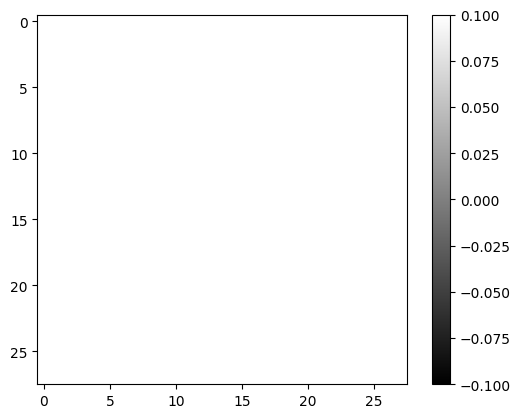

In [15]:
plt.imshow(tf.squeeze(imagens[0].numpy), cmap="gray")
plt.colorbar()
plt.show()

In [16]:
z = tf.random.normal((10, GENERATOR_LATENT_DIM))
imgs = gerador(z, training=False)

print(tf.reduce_min(imgs))
print(tf.reduce_max(imgs))
print(tf.math.reduce_any(tf.math.is_nan(imgs)))

tf.Tensor(nan, shape=(), dtype=float16)
tf.Tensor(nan, shape=(), dtype=float16)
tf.Tensor(True, shape=(), dtype=bool)


In [17]:
for v in gerador.trainable_variables:
    if tf.reduce_any(tf.math.is_nan(v)):
        print(v.name, "contém NaN")

kernel contém NaN
bias contém NaN
kernel contém NaN
bias contém NaN
kernel contém NaN
bias contém NaN
kernel contém NaN
bias contém NaN
gamma contém NaN
beta contém NaN
kernel contém NaN
bias contém NaN
kernel contém NaN
bias contém NaN
kernel contém NaN
bias contém NaN
gamma contém NaN
beta contém NaN
kernel contém NaN
bias contém NaN
kernel contém NaN
bias contém NaN
kernel contém NaN
bias contém NaN
kernel contém NaN
bias contém NaN
kernel contém NaN
bias contém NaN
kernel contém NaN
bias contém NaN
kernel contém NaN
bias contém NaN


In [18]:
gerador = criar_gerador()
z = tf.random.normal((10, GENERATOR_LATENT_DIM))
imgs = gerador(z, training=False)

print(tf.reduce_min(imgs))
print(tf.reduce_max(imgs))
print(tf.math.reduce_any(tf.math.is_nan(imgs)))

tf.Tensor(-0.552, shape=(), dtype=float16)
tf.Tensor(0.9697, shape=(), dtype=float16)
tf.Tensor(False, shape=(), dtype=bool)
